## IMPORT

In [1]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression

## CODE

In [2]:
try:
    df = pd.read_csv("../../Supervise.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

matrices = np.load('../../Matrice.npy', allow_pickle=True) # Ouvre les matrices

X = matrices # Donne les matrices en données afin qu'il classe les IRM des patients en fonction de leurs maladie
y = df["target"] # Donne les différentes maladies possibles

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=1
) # Split X et Y pour avoir une partie entraînement et une partie examen
clf = LogisticRegression()
clf = clf.fit(X_train, y_train) # Créer et entraîne le modèle

accuracy = clf.sccore(X_test, y_test) # Calcule la précision du bot ( le % d'IRM qu'il arrive a classer )

print("Accuracy :", accuracy) # Print la précision


y_pred = clf.predict(X_test)

print(confusion_matrix(y_test, y_pred)) # Créer la matrice de précision pour savoir avec plus de précision comment le bot arrive à classer les différentes maladies genre à combien de pourcent il devine que les patients atteint de stone sont atteint de stone.

raise SystemExit(0)


AttributeError: 'LogisticRegression' object has no attribute 'sccore'

## LOGISTIC REGRESSION

Elle attribue un poids à chaque pixel des images puis elle fais une somme pondérée de ces poids puis elle transforme ces poids en proba en utilisant une fonction appelé sigmoïd pour transformer le score en valeur entre 0 et 1 et ensuite attrabue à la classe l'image en fonction de quelle classe à la proba la plus élevée pour cette classe.

Pour apprendre ces poids le modèle fais des préductions puis calculs une erreur à partir des ces prédictions appélée la log loss puis il modifie ces poids pour essayer des faire de meilleurs prédiction.

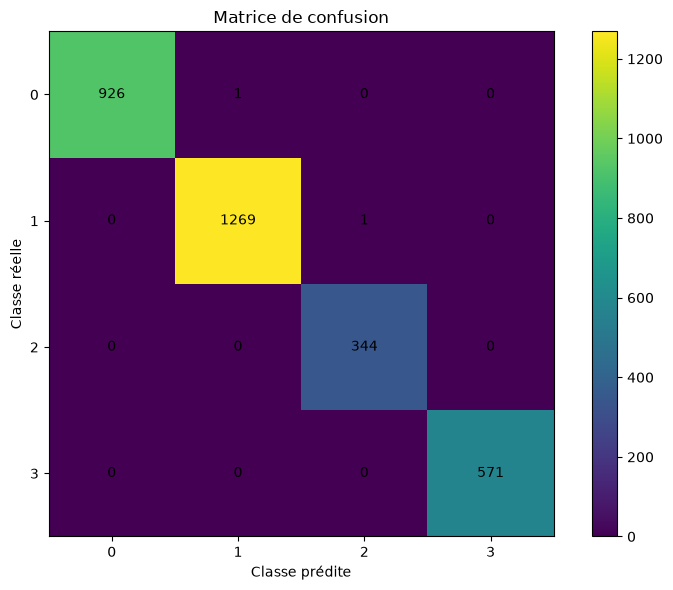

In [3]:
y_pred = clf.predict(X_test)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Création du graphique
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm)

# Noms des classes
classes = clf.classes_

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))

ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Ajouter les nombres dans les cases
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j],
                ha="center",
                va="center")

ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")
ax.set_title("Matrice de confusion")

plt.colorbar(im)
plt.tight_layout()
plt.show()